### Contents:
1. Loading up NCDF Files
2. Lat & Lon Correction + subset for North Atlantic and Extratropical Northern Hemisphere
3. Time indexes for ablation (MJJAS) and accumulation (DJF)
4. SVD for NAO index construction
     [Spatial + Time series plot for EOF: NAO (DJF + MJJAS)]
5. PCA for AO index construction 
     [Spatial + Time series plot for EOF: AO]

In [1]:
%reset

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.linalg import svd
import dask
from sklearn.preprocessing import StandardScaler

In [2]:
#file_path = "/Users/syeddanish.ali/Desktop/Danish/ERA5 Data/data_1.nc"
file_path = r"C:\Users\danis\Desktop\Danish\ERA5 Data\msl.nc"
#ds = xr.open_dataset(file_path, chunks = {"valid_time": 50})
ds = xr.open_dataset(file_path, chunks = {"time": 50})
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 902, latitude: 721, longitude: 1440)
Coordinates:
    number     int64 8B ...
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-02-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     (time) <U4 14kB dask.array<chunksize=(50,), meta=np.ndarray>
Data variables:
    msl        (time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>


C:\Users\danis\AppData\Local\Temp\ipykernel_12932\892630518.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(file_path, chunks = {"time": 50})


In [3]:
lat = ds.latitude.values
lat_index = np.where((lat >= 20) & (lat <= 80))[0]

lon_vals = ds.longitude.values
lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
lon_index = np.where((lon_vals >= -90) & (lon_vals <= 40))[0]

lon_index_sorted = lon_index[np.argsort(lon_vals[lon_index])]
lon_subset = lon_vals[lon_index_sorted]

complete_time = pd.to_datetime(ds["time"].values) 
months = pd.to_datetime(ds["time"].values).month
djf_index = np.where(np.isin(months, [12, 1, 2]))[0]
# for ablation
ablation_index = np.where(np.isin(months, [5, 6, 7, 8, 9]))[0]

In [14]:
# Select subset and load into memory
slp = ds["msl"]
#slp_djf = slp.isel(time=djf_index, latitude=lat_index, longitude=lon_index).load()

slp_ablation = slp.isel(time = ablation_index, latitude = lat_index, longitude = lon_index).load()

In [15]:
#slp = slp_djf
slp = slp_ablation
slp_np = slp.values

In [16]:
slp_np.shape  # Should print (ntime, nlat, nlon)

# for DJF: (227, 241, 521)
# for ablation: (375, 241, 521)

(375, 241, 521)

In [17]:
slp_mean = np.nanmean(slp_np, axis = 0)
slp_anom = slp_np - slp_mean
slp_sd = np.nanstd(slp_anom, axis = 0)
slp_std = slp_anom / slp_sd
ntime, nlat, nlon = slp_std.shape

#edited part
lat_subset = ds.latitude.isel(latitude=lat_index).values
weights = np.sqrt(np.cos(np.deg2rad(lat_subset)))  # shape: (nlat,)
weights_2d = weights[:, np.newaxis]  # reshape to (nlat, 1)
slp_weighted = slp_std * weights_2d
slp_matrix = slp_weighted.reshape(ntime, nlat * nlon)

#slp_matrix = slp_std.reshape(ntime, nlat * nlon)

In [18]:
U, s, Vt = svd(slp_matrix, full_matrices=False) # U is PCs (how the pattern varies over time); 
                                                  # S is singular values (importance of each pattern used to compute variance;
                                                  # Vt is V transposed; spatial pattern of U, rows = modes
variance_explained = (s**2) / np.sum(s**2) * 100
print(variance_explained[:5]) # 37.4811 for DJF & 27.9768% for MMJAS

[23.02054622 19.38717378 12.30701978  7.12366879  5.52701697]


#### Extracting DJF mode

In [ ]:
EOF1_DJF = Vt[0, :].reshape(nlat, nlon)  # Vt has shape  (n_modes, n_gridpoints) so we choose a mode and all the corresponding grid points
EOF2_DJF = Vt[1, :].reshape(nlat, nlon)
EOF1_DJF = -EOF1_DJF

In [10]:
print("EOF1 shape:", EOF1_DJF.shape)
print("Lat:", len(lat[lat_index]))
print("Lon:", len(lon_vals[lon_index]))
np.isnan(EOF1_DJF).sum()


EOF1 shape: (241, 521)
Lat: 241
Lon: 521


np.int64(0)

#### Extracting MJJAS mode

In [10]:
EOF1_MJJAS = Vt[0, :].reshape(nlat, nlon)  # Vt has shape  (n_modes, n_gridpoints) so we choose a mode and all the corresponding grid points
EOF2_MJJAS = Vt[1, :].reshape(nlat, nlon)
EOF1_MJJAS = -EOF1_MJJAS

In [11]:
print("EOF1 shape:", EOF1_MJJAS.shape)
print("Lat:", len(lat[lat_index]))
print("Lon:", len(lon_vals[lon_index]))
np.isnan(EOF1_MJJAS).sum()


EOF1 shape: (241, 521)
Lat: 241
Lon: 521


np.int64(0)

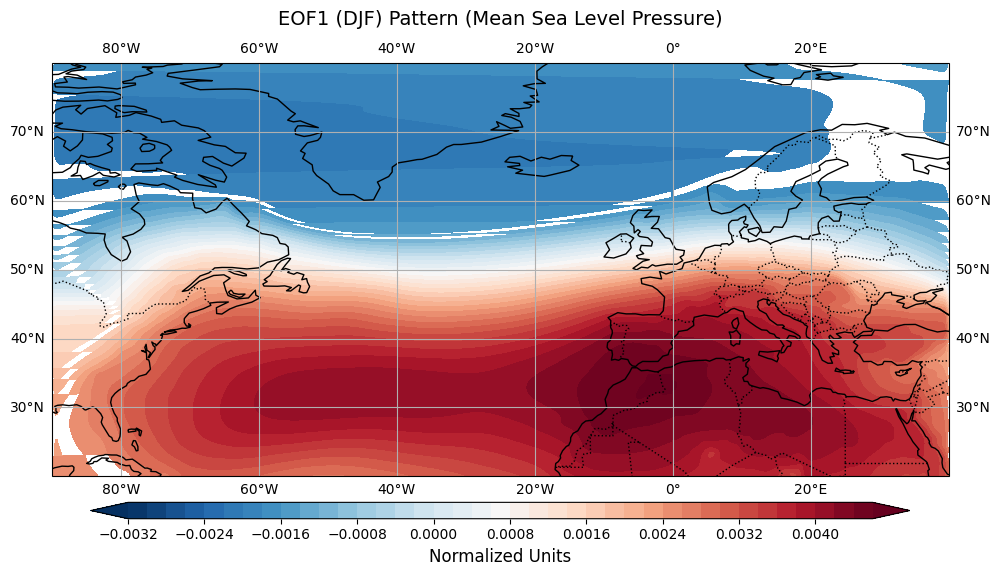

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(12, 6))
# this is to add a map axis with projection 
ax = plt.axes(projection=ccrs.PlateCarree()) # mercator 

from scipy.ndimage import gaussian_filter
EOF1_DJF_smooth = gaussian_filter(EOF1_DJF, sigma=1.5)


# plotting the eof1 pattern
contour = ax.contourf(
    lon_vals[lon_index],          # x-axis values (longitudes)
    lat[lat_index],               # y-axis values (latitudes)
    EOF1_DJF_smooth,                         # data to plot (2D array)
    levels=40,                    # number of contour levels
    cmap= "RdBu_r",                # red-blue reversed colormap
    extend= "both",                # allow colors to extend past min/max
    transform=ccrs.PlateCarree()  # the data's native projection
)


# Add coastlines and gridlines
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Title and colorbar
ax.set_title("EOF1 (DJF) Pattern (Mean Sea Level Pressure)", fontsize=14, pad=12)
cb = plt.colorbar(contour, orientation="horizontal", pad=0.05, aspect=50, shrink=0.7)
cb.set_label("Normalized Units", fontsize=12)

plt.tight_layout()
#plt.savefig("EOF1_MJJAS_Plot.png", dpi=800, bbox_inches="tight")
plt.show()


In [13]:
PC1_MJJAS = U[: ,0] # shape : [n_time, n_modes], so we want the time series for one particular mode
PC2_MJJAS = U[: ,1]
PC1_std_MJJAS = (PC1_MJJAS - PC1_MJJAS.mean())/PC1_MJJAS.std()
PC2_std_MJJAS = (PC2_MJJAS - PC2_MJJAS.mean())/PC2_MJJAS.std()

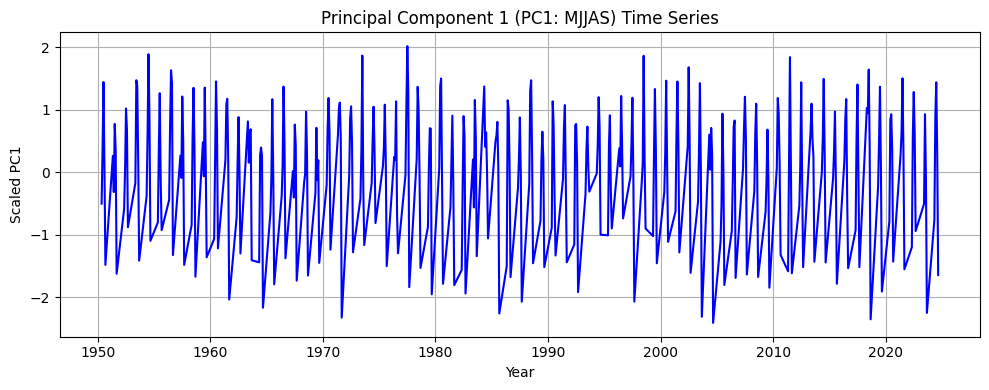

In [14]:
# plotting time series PC1
plt.figure(figsize=(10, 4))
plt.plot(complete_time[ablation_index], PC1_std_MJJAS, color="blue", linewidth=1.5)
plt.title("Principal Component 1 (PC1: MJJAS) Time Series")
plt.xlabel("Year")
plt.ylabel("Scaled PC1")
plt.grid(True)
plt.tight_layout()
#plt.savefig("PC1_MJJAS_TimePlot.png", dpi=800, bbox_inches="tight")
plt.show()


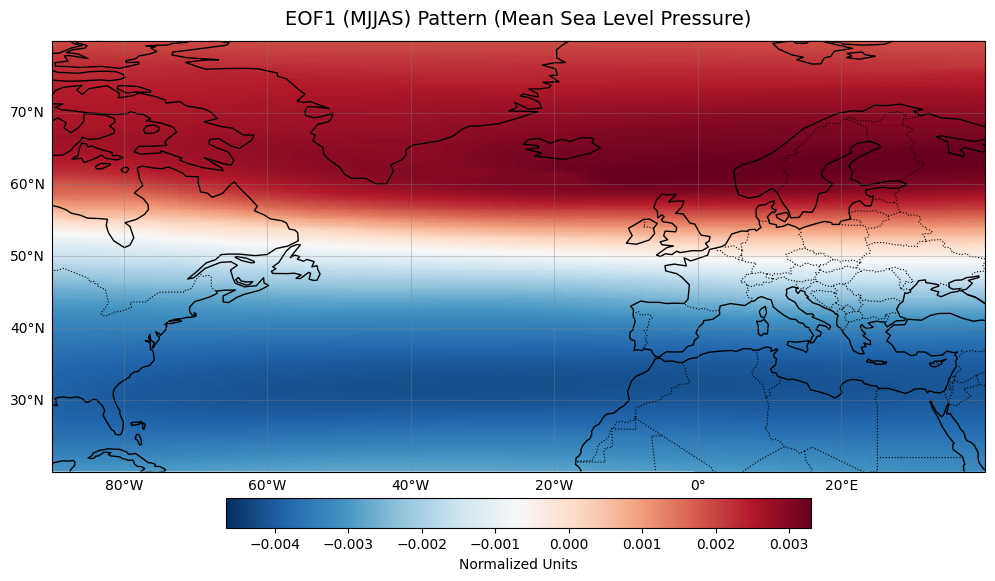

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create figure and axis with PlateCarree projection
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree()) # or mercator?

# Plot the data using pcolormesh (better than contourf for non-global maps)
mesh = ax.pcolormesh(
    lon_index_sorted,       # X-axis (longitude)
    lat[lat_index],            # Y-axis (latitude)
    -EOF1_DJF,                      # 2D EOF pattern to plot
    cmap="RdBu_r",             # Red-Blue reversed colormap
    shading="auto",            # prevents artifacts in plot
    transform=ccrs.PlateCarree()
)

# Add coastlines and borders
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
ax.set_extent([
    lon_vals[lon_index].min(), lon_vals[lon_index].max(),
    lat[lat_index].min(), lat[lat_index].max()
], crs=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False  # Turn off top and right labels

# Add colorbar
cb = plt.colorbar(mesh, orientation='horizontal', pad=0.05, shrink=0.5)
cb.set_label("Normalized Units")

# Title
ax.set_title("EOF1 (MJJAS) Pattern (Mean Sea Level Pressure)", fontsize=14, pad=12)

# Final layout
plt.tight_layout()
#plt.savefig("EOF1_MJJAS_Plot2.png", dpi=800, bbox_inches="tight")
plt.show()


In [30]:
# To save objects for subsequent use:
# For individual saving and loading up (respectively): 

# np.save("EOF1.npy", EOF1)
# EOF1= np.loaf("EOF1.npy")

# For saving up multiple arrays in one object:
eof_data_weighted = {
    "EOF1_DJF": EOF1_DJF,
    "EOF2_DJF": EOF2_DJF,
    "PC1_DJF": PC1_DJF,
    "PC2_DJF": PC2_DJF,
    "PC1_std_DJF": PC1_std_DJF,
    "PC2_std_DJF": PC2_std_DJF,
    
    "EOF1_MJJAS": EOF1_MJJAS,
    "EOF2_MJJAS": EOF2_MJJAS,
    "PC1_MJJAS": PC1_MJJAS,
    "PC2_MJJAS": PC2_MJJAS,
    "PC1_std_MJJAS": PC1_std_MJJAS,
    "PC2_std_MJJAS": PC2_std_MJJAS
}
import pickle 
with open("eof_data_weighted.pkl", "wb") as f:
    pickle.dump(eof_data_weighted, f)



In [104]:
#data = np.load("eof_data.npz")
#print(data.files)

# to open in later script:
with open("eof_data.pkl", "rb") as f:
    eof_data = pickle.load(f)

print(eof_data.keys())
# Access variables
# EOF1_DJF = eof_data["EOF1_DJF"]
# PC1_MJJAS = eof_data["PC1_MJJAS"]
# etc.

dict_keys(['EOF1_DJF', 'EOF2_DJF', 'PC1_DJF', 'PC2_DJF', 'PC1_std_DJF', 'PC2_std_DJF', 'EOF1_MJJAS', 'EOF2_MJJAS', 'PC1_MJJAS', 'PC2_MJJAS', 'PC1_std_MJJAS', 'PC2_std_MJJAS'])


### Constructing AO Index 

In [4]:
print(ds)
print(ds.coords)
print(ds['msl'].attrs)
# the unit is in Pa, and we need to convert it into hPa

<xarray.Dataset> Size: 15GB
Dimensions:     (valid_time: 902, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2025-02-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 14kB dask.array<chunksize=(50,), meta=np.ndarray>
Data variables:
    msl         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescrip

In [5]:
slp_hpa= ds['msl']/100
lat= ds.latitude.values
lat_vals_ao= np.where((lat>=20) & (lat<= 90)) #or just subset the entire dataset for the reqd latitude
ds_ao_subset= ds.sel(latitude= slice(90,20))
slp_ao_hpa= ds_ao_subset['msl']/100

monthly_climatology= slp_ao_hpa.groupby('valid_time.month').mean('valid_time')
monthly_anom= slp_ao_hpa.groupby('valid_time.month') - monthly_climatology

In [6]:
#area weigthing for converging meridians (Baldwin et. al 2007 & NCAR EOF and Rotated EOF Guide)
# extracting lat again from climatology data subset ^
lat_ao= monthly_anom.latitude
weights = np.sqrt(np.cos(np.deg2rad(monthly_anom.latitude)))  # xarray object with 'latitude' dims
weighted_anom = monthly_anom * weights

print(weighted_anom.dims)

# reshaping into 1D matrix for PCA
slp= weighted_anom.stack(space=("latitude", "longitude"))
slp_clean= slp.transpose("valid_time", "space").values

('valid_time', 'latitude', 'longitude')


In [10]:
# PCA calculation
from sklearn.decomposition import PCA
pca= PCA(n_components= 1)
ao_index= pca.fit_transform(slp_clean)[:, 0]
ao_index = (ao_index - ao_index.mean()) / ao_index.std()

In [11]:
print(ao_index[:10])
print(np.min(ao_index), np.max(ao_index))


[-0.22622131 -0.61905052 -0.20754763 -0.15281036 -0.30117651 -0.61529802
  0.56789467  0.50357876 -0.47700777 -0.00242154]
-3.8392925429284674 4.02532488757135


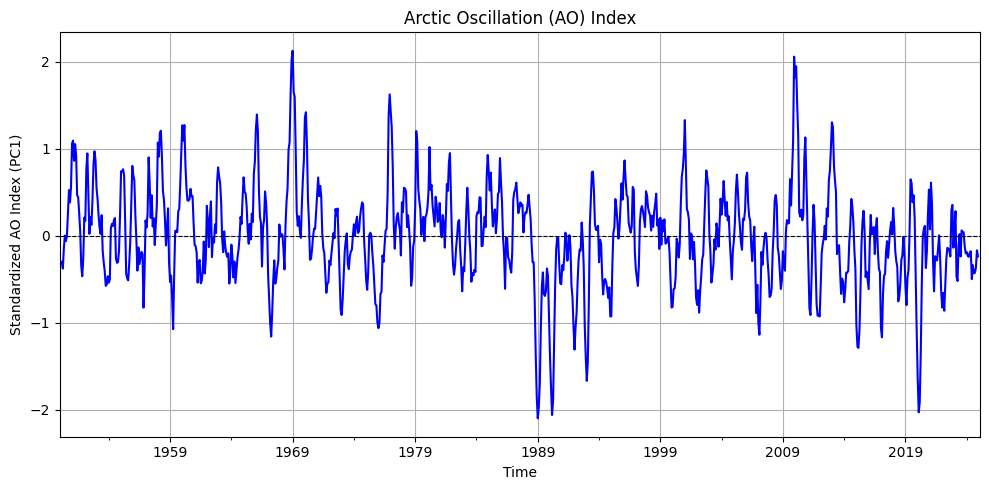

In [12]:
# Plotting
import matplotlib.pyplot as plt 
import pandas as pd
ao_time_series= pd.Series(ao_index, index= slp['valid_time'].values)
ao_smoothed= ao_time_series.rolling(window=5, center=True).mean()

plt.figure(figsize=(10,5))
ao_smoothed.plot(color= 'blue', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Arctic Oscillation (AO) Index")
plt.xlabel('Time')
plt.ylabel('Standardized AO Index (PC1)')
plt.grid(True)
plt.tight_layout()
plt.show()
               

In [13]:
EOF1_AO= pca.components_[0] # shape is (n_gridpoints, )
EOF1_AO= -EOF1_AO
EOF_AO = EOF1_AO * 1000
eof_map= xr.DataArray(EOF_AO, dims= ['space']).assign_coords(space= slp['space']).unstack()

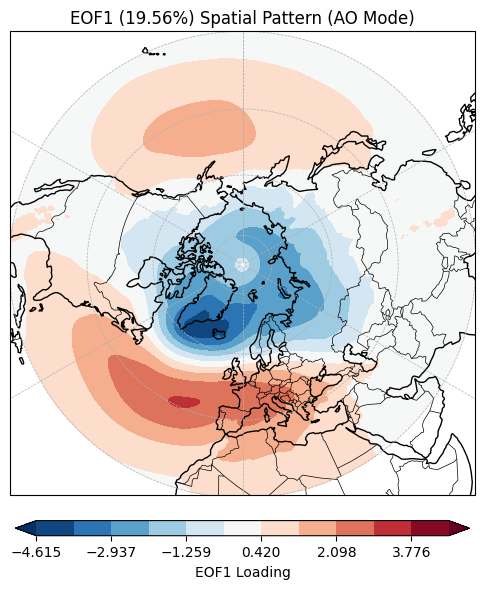

In [14]:
plt.figure(figsize=(12,6))
ax= plt.axes(projection= ccrs.NorthPolarStereo())

#eof_map.plot.pcolormesh(
 #   ax=ax,
  #  transform= ccrs.PlateCarree(),
   # cmap= 'RdBu_r',
    #shading= 'auto'
#)

lon= eof_map['longitude'].values
lat= eof_map['latitude'].values
lon2d, lat2d= np.meshgrid(lon,lat)
data= eof_map.values
data= np.ma.masked_where(lat2d<20, data)

vmax = np.max(np.abs(data))
levels = np.linspace(-vmax, vmax, 12)  # 21 evenly spaced levels centered at 0

contourf= ax.contourf(
    lon2d, lat2d, data,
    transform= ccrs.PlateCarree(),
    levels=levels,
    cmap= 'RdBu_r',
    extend= 'both',
)
contour= ax.contour(
    lon2d, lat2d, data,
    colors= 'black',
    levels=levels,
    linewidths= 0,
    transform= ccrs.PlateCarree()
)
cb= plt.colorbar(contourf, orientation='horizontal', pad=0.05, aspect= 30, fraction =0.03)
cb.set_label('EOF1 Loading')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth= 0.5)
ax.gridlines(draw_labels=False, linewidth= 0.5, linestyle='--')
ax.set_extent([-180,180, 20,90], crs= ccrs.PlateCarree())
ax.set_title('EOF1 (19.56%) Spatial Pattern (AO Mode)')
plt.tight_layout()
plt.savefig('AO_EOF1_Plot2.png', dpi=800, bbox_inches='tight')
plt.show()

In [11]:
explained_var = pca.explained_variance_ratio_[0] * 100
print(f"EOF1 explains {explained_var:.2f}% of total variance")


EOF1 explains 19.56% of total variance


In [15]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(slp_clean)
pc1 = pcs[:, 0]
pc2 = pcs[:, 1]


In [17]:
import pickle 
with open("eof_data_weighted.pkl", "rb") as f:
    eof_data_weighted = pickle.load(f)

print(eof_data_weighted.keys())

dict_keys(['EOF1_DJF', 'EOF2_DJF', 'PC1_DJF', 'PC2_DJF', 'PC1_std_DJF', 'PC2_std_DJF', 'EOF1_MJJAS', 'EOF2_MJJAS', 'PC1_MJJAS', 'PC2_MJJAS', 'PC1_std_MJJAS', 'PC2_std_MJJAS'])


In [18]:
# AO outputs
eof_data_weighted["PC1_AO"] = ao_index     # pandas Series
eof_data_weighted["EOF_AO_map"] = eof_map     
eof_data_weighted["EOF1_AO"]= EOF1_AO 

with open("eof_data_weighted.pkl", "wb") as f:
    pickle.dump(eof_data_weighted, f)

In [19]:
print(eof_data_weighted.keys())

dict_keys(['EOF1_DJF', 'EOF2_DJF', 'PC1_DJF', 'PC2_DJF', 'PC1_std_DJF', 'PC2_std_DJF', 'EOF1_MJJAS', 'EOF2_MJJAS', 'PC1_MJJAS', 'PC2_MJJAS', 'PC1_std_MJJAS', 'PC2_std_MJJAS', 'PC1_AO', 'EOF_AO_map', 'EOF1_AO'])
